<a href="https://colab.research.google.com/github/nimaghasemilearning/PyTorch-Tutorial/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Convert MNIST Image Files into a Tensor of 4-Dimension (# of images, Height, Width, Color Channel)
transform = transforms.ToTensor()

In [ ]:
# Train Data
train_data = datasets.MNIST(root='/cnn_data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 146MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 33.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 50.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.57MB/s]


In [ ]:
# Test Data
test_data = datasets.MNIST(root='/cnn_data', train=False, download=True, transform=transform)

In [ ]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
pwd

'/content'

In [ ]:
ls

sample_data/


In [ ]:
cd ../

/


In [ ]:
pwd

'/'

In [ ]:
ls

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [ ]:
cd cnn_data/

/cnn_data


In [ ]:
ls

MNIST/


In [ ]:
cd ../

/


In [ ]:
ls

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [ ]:
cd /content/

/content


In [ ]:
pwd

'/content'

In [ ]:
# Create a small batch size for images ... let's say 10
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(train_data, batch_size=10, shuffle=False)

In [ ]:
# Define Our CNN Model
# Describe convulutional later and what it's doing (2 convulutional layers)
# This is just an example in the next video we'll build out the actual model
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [ ]:
# Grab 1 MNIST record/image
for i, (X_Train, y_train) in enumerate(train_data):
  break

In [ ]:
X_Train.shape

torch.Size([1, 28, 28])

In [ ]:
x = X_Train.view(1,1,28,28)

In [ ]:
# Perform our first convolution
x = F.relu(conv1(x)) # Rectified Linear Unit for our activation function

In [ ]:
x.shape

torch.Size([1, 6, 26, 26])

In [ ]:
# pass thru the pooling layer
x = F.max_pool2d(x,2,2) # kernel of 2 and stride of 2

In [ ]:
x.shape

torch.Size([1, 6, 13, 13])

In [ ]:
# Do our second convolutional layer
x = F.relu(conv2(x))

In [ ]:
x.shape # Again, we didn't set padding so we lose 2 pixels around the outside of the image

torch.Size([1, 16, 11, 11])

In [ ]:
# Pooling layer
x = F.max_pool2d(x,2,2)

In [ ]:
x.shape # 11 / 2 = 5.5 but we have to round down, because you can't invent data to round up

torch.Size([1, 16, 5, 5])

In [ ]:
# Model Class
class ConvulutionnalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    # Fully connected layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2) # 2x2 kernel and stride 2
    # Second Pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2) # 2x2 kernel and stride 2

    # Re_View to flatten it out
    X = X.view(-1, 16*5*5) # negative one so that we can vary the batch size

    # Fully Connected Layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim=1)

In [ ]:
# Create an Instance of our Model
torch.manual_seed(41)
model = ConvulutionnalNetwork()
model

ConvulutionnalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Smaller the Learning Rate, longer its gonna take to train.

In [ ]:
import time
start_time = time.time()

# Create Variables to Tracks Things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []


# For Loop of Epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0


  # Train
  for b,(X_train, y_train) in enumerate(train_loader):
    b+=1 # Start our batches at 1
    y_pred = model(X_train) # get predicted values from the training set. not flattened
    loss = criterion(y_pred, y_train) # how off are we? Compare the predictions to correct answers

    predicted = torch.max(y_pred.data, 1)[1] # add up the number of correct predictions. indexed off the first point
    batch_corr = (predicted == y_train).sum() # how many we got correct from this batch. True = 1, False=0, sum those up.
    trn_corr += batch_corr # keep track as we go along in training

    # Update our parameter
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print ou some results
    if b%600 == 0:
      print(f"Epoch: {i} Batch: {b} Loss: {loss.item()}")

    train_losses.append(loss.item())
    train_correct.append(trn_corr)

    # Test
    with torch.no_grad():
      for b, (X_test, y_test) in enumerate(test_loader):
        y_val = model(X_test)
        predicted = torch.max(y_val.data, 1)[1]
        tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss.item())
    test_correct.append(tst_corr)

current_time = time.time()
total = current_time - start_time
print(f"Training Took: {total/60} minutes!")

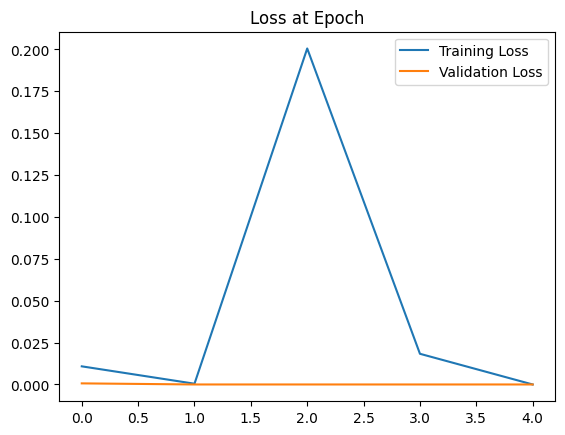

In [ ]:
# Graph the loss at epoch
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")
plt.title("Loss at Epoch")
plt.legend()

In [ ]:
print(len(train_losses), len(test_losses))
print(train_losses)

5 1
[0.006532256957143545, 0.0010717313271015882, 0.00041818077443167567, 1.3351400411920622e-06, 1.4471033864538185e-05]


In [ ]:
print(len(test_losses), len(train_losses))
print(test_losses)

5 5
[0.0006584414513781667, 6.758949893992394e-06, 3.7192680792941246e-06, 1.1920907354578958e-06, 5.268936547508929e-06]


In [ ]:
print(len(test_losses))
print(test_losses)

5
[0.0006584414513781667, 6.758949893992394e-06, 3.7192680792941246e-06, 1.1920907354578958e-06, 5.268936547508929e-06]
